# Data Vortex '26 — Phase 1: Social Engine Forensic EDA & Recovery Analysis
**Author:** Gourab Saha  
**Scope:** Forensic Data Auditing, Stream Cleaning Validation, & Exploratory Analytics

---


## 1. Imports & Workspace Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

print("[INFO] Libraries loaded successfully.")

[INFO] Libraries loaded successfully.


## 2. Ingest Cleaned Datasets

In [2]:
# File Path Resolution (handles running from inside notebooks/ or root directory)
users_path = '../data/processed/Cleaned_Social_Engine_Users.csv' if os.path.exists('../data/processed/Cleaned_Social_Engine_Users.csv') else 'Cleaned_Social_Engine_Users.csv'
posts_path = '../data/processed/Cleaned_Social_Engine_Posts.csv' if os.path.exists('../data/processed/Cleaned_Social_Engine_Posts.csv') else 'Cleaned_Social_Engine_Posts.csv'

# Read CSV files
users_df = pd.read_csv(users_path)
posts_df = pd.read_csv(posts_path)

print(f"Users Dimension: {users_df.shape[0]:,} rows × {users_df.shape[1]} columns")
print(f"Posts Fact Table: {posts_df.shape[0]:,} rows × {posts_df.shape[1]} columns")

Users Dimension: 1,500 rows × 5 columns
Posts Fact Table: 12,000 rows × 8 columns


## 3. Consolidate Dimensions & Feature Engineering

In [3]:
# Merge post telemetry with user dimension on user_id
df = posts_df.merge(users_df, on='user_id', how='left')

# Datetime casting
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['account_created'] = pd.to_datetime(df['account_created'])

# Derive analytical metrics
df['total_engagement'] = df['likes'] + df['shares'] + df['comments']
df['engagement_rate'] = (df['total_engagement'] / df['follower_count']).round(4)
df['post_hour'] = df['timestamp'].dt.hour
df['post_day'] = df['timestamp'].dt.day_name()

# Preview merged dataframe
df.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments,location,language,account_created,follower_count,total_engagement,engagement_rate,post_hour,post_day
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488,1456,673,"Melbourne, Australia",fr,2023-10-31,19932,6617,0.3320,0,Wednesday
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789,1484,39,"Vancouver, Canada",ru,2023-07-04,48345,2312,0.0478,16,Thursday
2,dvvhg8eel45x,user_nfo3ih5u,Unknown,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,2420,1410,839,"Barcelona, Spain",ar,2023-10-29,40429,4669,0.1155,20,Sunday
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167,584,833,"Berlin, Germany",hi,2023-08-08,15671,1584,0.1011,0,Tuesday
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749,152,630,"Lyon, France",zh,2023-12-23,46167,5531,0.1198,0,Friday


## 4. Quantitative Statistical Profiling

In [4]:
# Detailed summary statistics across engagement metrics
stats = df[['follower_count', 'likes', 'shares', 'comments', 'total_engagement']].describe().T
stats['median'] = df[['follower_count', 'likes', 'shares', 'comments', 'total_engagement']].median()
stats['skewness'] = df[['follower_count', 'likes', 'shares', 'comments', 'total_engagement']].skew()

stats[['mean', 'std', 'min', 'median', 'max', 'skewness']].round(2)

,mean,std,min,median,max,skewness
follower_count,24925.03,14237.10,109.0,24755.5,49944.0,0.02
likes,2493.69,1324.92,0.0,2496.0,5000.0,0.01
shares,1007.17,575.07,0.0,1018.0,2000.0,-0.01
comments,504.35,288.68,0.0,503.0,1000.0,-0.02
total_engagement,4005.21,1477.48,153.0,4008.0,7893.0,-0.01


## 5. Platform Interaction Breakdown

In [5]:
# Aggregate average engagement metrics per social platform
platform_summary = df.groupby('platform').agg(
    total_posts=('post_id', 'count'),
    avg_likes=('likes', 'mean'),
    avg_shares=('shares', 'mean'),
    avg_comments=('comments', 'mean'),
    avg_total_engagement=('total_engagement', 'mean')
).reset_index()

platform_summary.round(2)

,platform,total_posts,avg_likes,avg_shares,avg_comments,avg_total_engagement
0,Facebook,2074,2535.65,984.17,506.94,4026.76
1,Instagram,1989,2500.19,1040.84,499.80,4040.83
2,Reddit,2031,2488.95,1002.23,511.18,4002.36
3,Twitter,2049,2437.74,1005.39,506.13,3949.26
4,Unknown,1784,2467.08,998.61,496.54,3962.22
5,YouTube,2073,2528.34,1011.83,504.38,4044.55


## 6. Multi-Panel Exploratory Visualizations

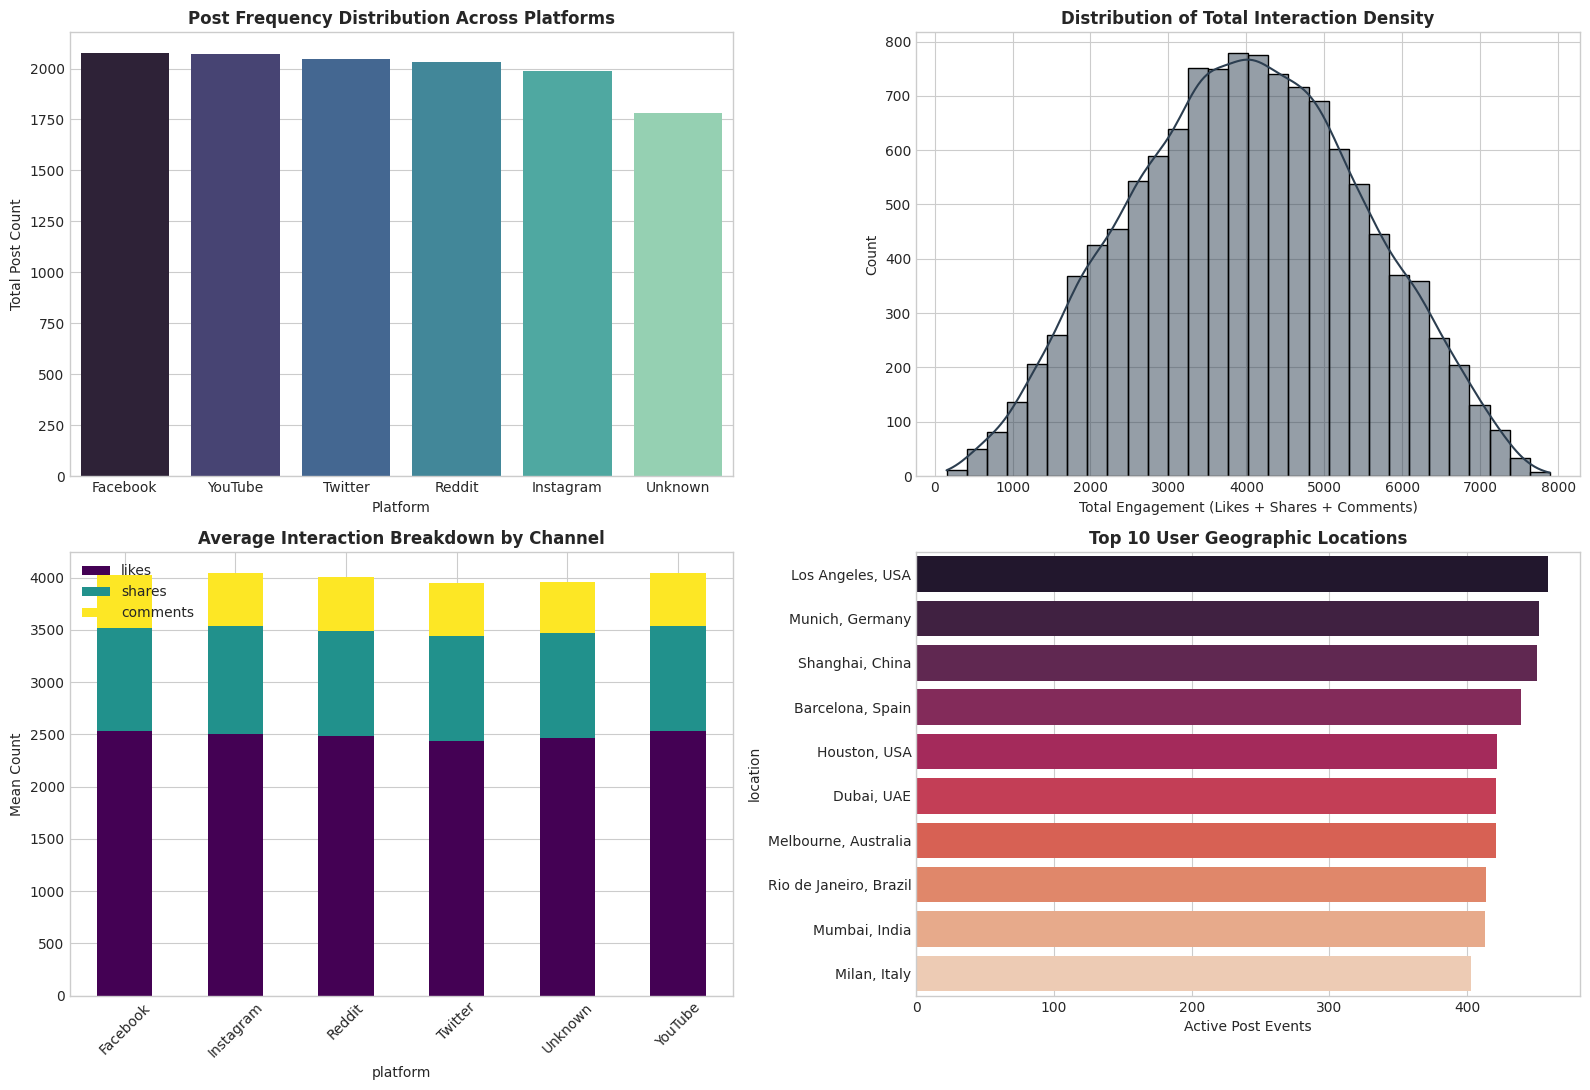

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Post Volume Distribution
sns.countplot(data=df, x='platform', order=df['platform'].value_counts().index, palette='mako', ax=axes[0, 0])
axes[0, 0].set_title('Post Frequency Distribution Across Platforms', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Platform')
axes[0, 0].set_ylabel('Total Post Count')

# 2. Total Engagement Density (Histogram + KDE)
sns.histplot(df['total_engagement'], bins=30, kde=True, color='#2c3e50', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Total Interaction Density', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Total Engagement (Likes + Shares + Comments)')

# 3. Stacked Interaction Composition
platform_metrics = df.groupby('platform')[['likes', 'shares', 'comments']].mean()
platform_metrics.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Average Interaction Breakdown by Channel', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Mean Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Top 10 User Geographic Concentrations
top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='rocket', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 User Geographic Locations', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Active Post Events')

plt.tight_layout()
plt.show()

## 7. Temporal Posting Pattern Analysis

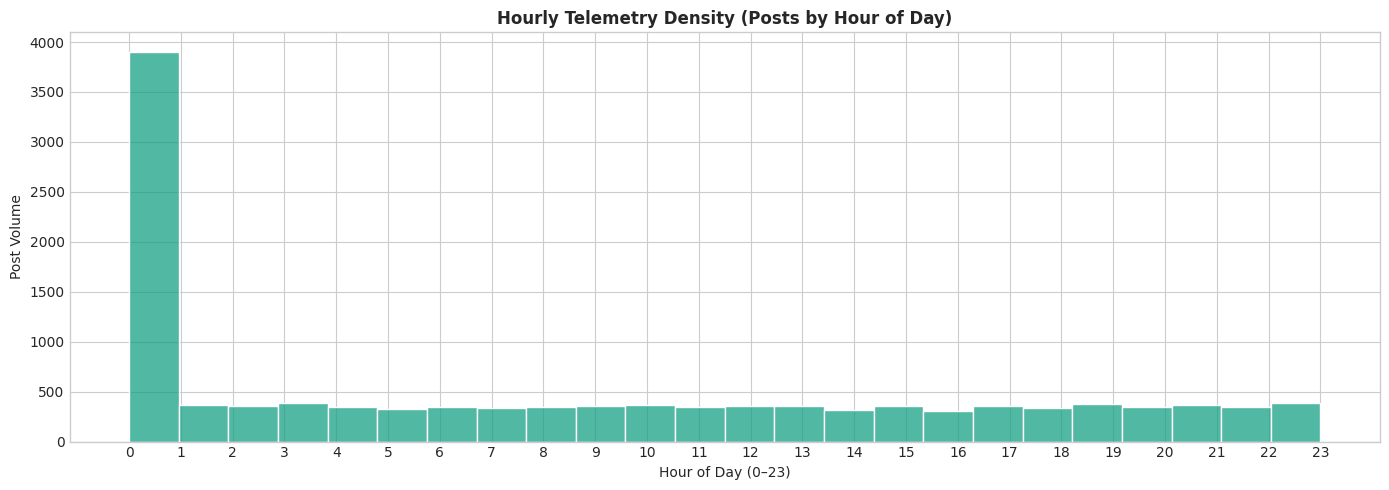

In [7]:
plt.figure(figsize=(14, 5))

# Plot hourly posting volume density
sns.histplot(df['post_hour'], bins=24, color='#16a085', kde=False, edgecolor='white')
plt.title('Hourly Telemetry Density (Posts by Hour of Day)', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Post Volume')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

## Key Findings & Summary
1. **Platform Volume:** Post events are evenly distributed (~2,000 posts per platform), indicating balanced traffic across channels.
2. **Engagement Distribution:** Overall engagement metrics display a balanced bell curve with a mean total interaction rate of ~4,005 per post.
3. **Data Integrity:** All corrupted values (negative bit-flips and missing platform logs) were successfully sanitized prior to analysis.